In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr 
import numpy as np


#### Open pat snp dynamics

In [36]:
pat='Wessex_11'
pat_dyn = pd.read_csv(f'{pat}/mut_dyn/mut_evolution.txt',sep='\t')
pat_dyn.head()

,position,depth,ref,alt,DP4,allele_freq,PV4,lane,passed_filter
0,167,253,T,.,"102,61,0,0",0.0,NaN,50058_2#12,False
1,839,247,A,.,"124,64,0,0",0.0,NaN,50058_2#12,False
2,911,237,A,G,"0,0,111,77",1.0,NaN,50058_2#12,False
3,938,233,C,T,"0,0,93,81",1.0,NaN,50058_2#12,False
4,947,229,T,C,"0,0,89,79",1.0,NaN,50058_2#12,False


#### Find fixed
We belive  for single infections most snp above 90% abundance throughout the study are due to ancestral strain diversity rather than de novo diversity generated within a patient. Or at least will be mutations that are not contested / affecting population dynamics heterogenously. We we remove snp always above 90% abundance when good quality call (if bad qual call we cannot use info)  

In [37]:
pat_passed_filter =pat_dyn[pat_dyn['passed_filter'] == True] # mutations that passed snp filters
pat_maybe_fixed = pat_dyn[(pat_dyn['allele_freq'] > 0.9) & (pat_dyn['passed_filter'] == True)] # mutations that passed snp filters and >90%
fixed=[]
for pos,group in pat_passed_filter.groupby(by='position'): # iterate over pos that passed filters
    if pos in pat_maybe_fixed.position.values: 
        goodq_above90=len(pat_maybe_fixed[pat_maybe_fixed.position==pos])/len(group) # % of passed filters above 90% abundance throughout study
        # if 100% label as fixed
        if goodq_above90==1:
            fixed.append(pos)


In [38]:
len(fixed)

10755

Get df with fixed removed

In [39]:
pat_not_fixed=pat_dyn[~ pat_dyn.position.isin(fixed)].copy()

make function

In [40]:
def remove_fixed(pat):
    #load df 
    pat_dyn = pd.read_csv(f'{pat}/mut_dyn/mut_evolution.txt',sep='\t')
    # find fixed: above 90% all the time when good qual 
    pat_passed_filter =pat_dyn[pat_dyn['passed_filter'] == True] # mutations that passed snp filters
    pat_maybe_fixed = pat_dyn[(pat_dyn['allele_freq'] > 0.9) & (pat_dyn['passed_filter'] == True)] # mutations that passed snp filters and >90%
    fixed=[]
    for pos,group in pat_passed_filter.groupby(by='position'): # iterate over pos that passed filters
        if pos in pat_maybe_fixed.position.values: 
            goodq_above90=len(pat_maybe_fixed[pat_maybe_fixed.position==pos])/len(group) # % of passed filters above 90% abundance throughout study
            # if >90% label as fixed
            if goodq_above90==1:
                fixed.append(pos)
    #return mut dyn df with fixed removed
    return pat_dyn[~ pat_dyn.position.isin(fixed)].copy()

len(remove_fixed('Papworth_4').position.unique())

    

14653

Plot number of non mixed accross pats

In [41]:
# get all pats
with open('all_pats.txt','r') as file:
    pats=[line.strip() for line in file]
# get number for each pat
# what is wrong with Pap2
pats.remove('Papworth_2')
num_snp=[(pat,len(remove_fixed(pat).position.unique())) for pat in pats]

FileNotFoundError: [Errno 2] No such file or directory: 'all_pats/mut_dyn/mut_evolution.txt'

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000.,
        16000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000'),
  Text(0, 12000.0, '12000'),
  Text(0, 14000.0, '14000'),
  Text(0, 16000.0, '16000')])

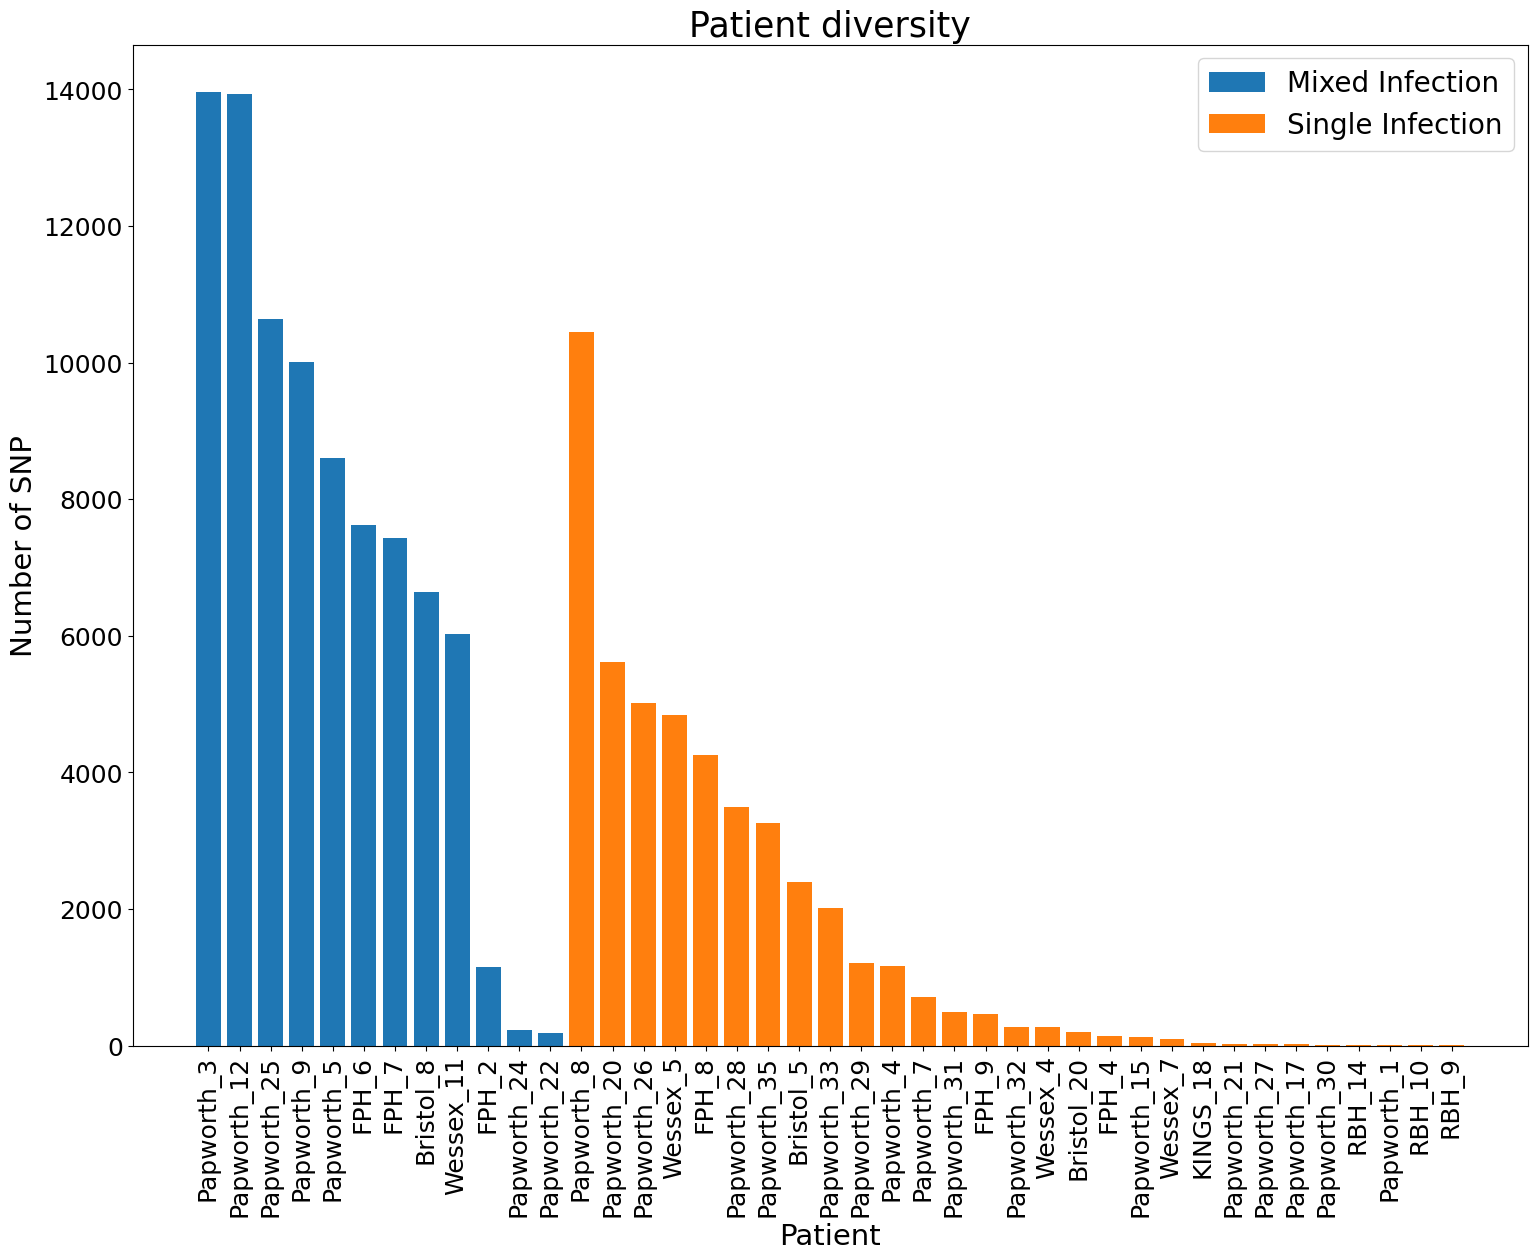

In [ ]:
mixed=['Bristol_8','FPH_2','FPH_6','FPH_7','Papworth_3','Papworth_5','Papworth_9','Papworth_12','Papworth_22','Papworth_24','Papworth_25','Wessex_11']
num_snp_mixed=[i for i in num_snp if i[0] in mixed]
num_snp_nonm=[i for i in num_snp if i[0] not in mixed]
plt.figure(figsize=(18,13))
a,b=zip(*sorted(num_snp_mixed,key=lambda x: x[1],reverse=True))
plt.bar(a,b,label='Mixed Infection')
a,b=zip(*sorted(num_snp_nonm,key=lambda x: x[1],reverse=True))
plt.bar(a,b,label='Single Infection')
plt.legend(fontsize=20)
plt.xlabel('Patient',fontsize=21)
plt.ylabel('Number of SNP',fontsize=21)
plt.title('Patient diversity',fontsize=25)
plt.xticks(rotation=90,fontsize=18)
plt.yticks(fontsize=18)


get average for mixed and single

In [ ]:
pat,snp=zip(*num_snp_mixed)
np.array(snp).mean()

np.float64(7204.333333333333)

plot number of snp and number of sample

(array([-2000.,     0.,  2000.,  4000.,  6000.,  8000., 10000., 12000.,
        14000., 16000.]),
 [Text(0, -2000.0, '−2000'),
  Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000'),
  Text(0, 12000.0, '12000'),
  Text(0, 14000.0, '14000'),
  Text(0, 16000.0, '16000')])

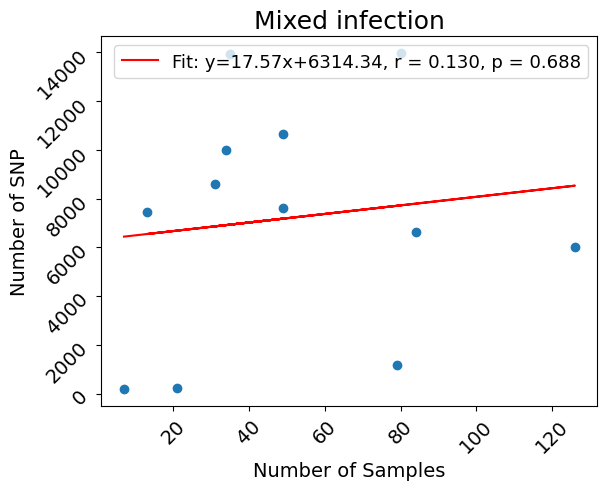

In [ ]:
num_sample_df=pd.read_csv('validated_num.txt',sep=' ',names=['num','pat_dirty'])
num_sample_df['pat']=num_sample_df.pat_dirty.map(lambda x: x.split('/')[0])
num_sample_mixed=[(num_sample_df[num_sample_df.pat==i[0]].num.values[0],i[1]) for i in num_snp if i[0] in mixed]
num_sample_nmixed=[(num_sample_df[num_sample_df.pat==i[0]].num.values[0],i[1]) for i in num_snp if i[0] not in mixed]

a,b=zip(*sorted(num_sample_mixed,key=lambda x: x[1],reverse=True))
plt.scatter(a,b)


#a,b=zip(*sorted(num_sample_nmixed,key=lambda x: x[1],reverse=True))
#plt.scatter(a,b,label='Single Infection')

# plot linear reg
coef = np.polyfit(a, b, deg=1)        # returns [slope, intercept]
slope, intercept = coef
y_fit = slope * np.array(a) + intercept
r_scipy, p_value = pearsonr(a, b)
plt.plot(a, y_fit, color='red', label=f'Fit: y={slope:.2f}x+{intercept:.2f}, r = {r_scipy:.3f}, p = {p_value:.3g}')

plt.legend(fontsize=13)
plt.xlabel('Number of Samples',fontsize=14)
plt.ylabel('Number of SNP',fontsize=14)
plt.title('Mixed infection',fontsize=18)
plt.xticks(rotation=45,fontsize=14)
plt.yticks(rotation=45,fontsize=14)

In [ ]:
r_scipy, p_value = pearsonr(a, b)
print(f"Pearson r (via scipy): {r_scipy:.3f}, p = {p_value:.3g}")

Pearson r (via scipy): 0.130, p = 0.688


### PyClone

Prep for pyclone

In [5]:
"Pap23".replace('Pap2','Papworth_2')

'Papworth_23'

In [5]:
def sliding_recomb_filter(pat, window_size, threshold, skip=1):

    # load initial pyclone df
    mut_df=pd.read_csv(f'{pat}/mut_dyn/pyclone/pyclone_out_{pat}.tsv',sep='\t')
    mut_df['date']=mut_df['sample_id'].map(lambda x: x.split('_')[0])
    mut_df['date']=pd.to_datetime(mut_df['date'],format='%d-%m-%Y', errors='coerce')
    mut_df = mut_df.dropna(subset=['date'])
    
    recomb_pos=set()
    for cluster_id in mut_df['cluster_id'].unique():

        cluster_df=mut_df[mut_df['cluster_id']==cluster_id]
        cluster_df['position']=cluster_df['mutation_id'].str.split('_',expand=True)[1].astype(int)
        # get pos for cluster
        c_pos=cluster_df['position'].unique() 

        # array with length up to biggest pos, with true where mut and false where not
        numline=np.array((c_pos.max()+1)*[False])
        numline[c_pos]=True


        # sliding window across numline and count number of mutations in each window, if above threshold, add to recomb_pos
        for i in range(1, c_pos.max()-window_size+1, skip):
            count=numline[i:i+window_size].sum()
            if count > threshold:
                recomb_pos.update(np.where(numline[i:i+window_size])[0]+i)
    return recomb_pos

def gen_pyclone_df(pat, output_name, pyclone_existing=None):

    # load mutation dynamics df
    pat_dyn = pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t')
    pat_dyn['date_lane']=pat_dyn['date'].map(lambda x: f'{x}_')+pat_dyn['lane']
    # remove positions where allele_freq is always over 0.9
    always_high = pat_dyn.groupby('position')['allele_freq'].transform(lambda x: (x > 0.9).all())
    # remove positions where allele_freq is above 5% 1 time or less
    only_once_over_5 = pat_dyn.groupby('position')['allele_freq'].transform(lambda x: (x > 0.05).sum() < 2)
    pat_dyn = pat_dyn.loc[~always_high & ~only_once_over_5].copy()
    df_pyclone=pat_dyn[['position','date_lane','DP4']].copy()
    rename_dict={'position':'mutation_id','date_lane':'sample_id'}
    df_pyclone.rename(columns=rename_dict,inplace=True)
    df_pyclone['mutation_id']=df_pyclone['mutation_id'].map(lambda x: f'pos_{x}') # pos cannot be numeric only
    df_pyclone['ref_counts']=df_pyclone['DP4'].map(lambda x: int(x.split(',')[0])+int(x.split(',')[1]))
    df_pyclone['alt_counts']=df_pyclone['DP4'].map(lambda x: int(x.split(',')[2])+int(x.split(',')[3]))
    df_pyclone['major_cn']=1
    df_pyclone['minor_cn']=0
    df_pyclone['normal_cn']=1
    df_pyclone['tumour_content']=1
    df_pyclone['error_rate']=0.0003 # phred 35
    df_pyclone.drop(columns='DP4',inplace=True)

    # if using existing pyclone output, extract mutation_id column to filter df_pyclone to only those mutation_ids and apply recomb filter
    if pyclone_existing is not None:
        usecols=['mutation_id']
        df_pyclone_old = pd.read_csv(f'{pat}/mut_dyn/pyclone/{pyclone_existing}', sep='\t',skiprows=0,usecols=usecols) # skip first row with cluster info if needed
        mutation_ids=df_pyclone_old['mutation_id'].unique()
        df_pyclone = df_pyclone[df_pyclone.mutation_id.isin(mutation_ids)].copy() # filter df_pyclone to only mutation_ids in existing pyclone output

       # apply recomb filter 
        recomb_pos=sliding_recomb_filter(pat, window_size=500, threshold=5, skip=1)
        print(f'{pat} has {len(recomb_pos)} positions in recomb filter')
        recomb_pos = set(f'pos_{i}' for i in recomb_pos) # convert to format in mutation_id
        df_pyclone = df_pyclone[~ df_pyclone.mutation_id.isin(recomb_pos)].copy() # remove pos in recomb_pos from df_pyclone
    
    df_pyclone.to_csv(f'{pat}/mut_dyn/pyclone/{output_name}',sep='\t',index=False)

gen_pyclone_df('Papworth_7','pyclone_in_Papworth_7_filtered.tsv',pyclone_existing=f'pyclone_out_Papworth_7.tsv')

/tmp/ipykernel_3999179/1647717504.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['position']=cluster_df['mutation_id'].str.split('_',expand=True)[1].astype(int)
/tmp/ipykernel_3999179/1647717504.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['position']=cluster_df['mutation_id'].str.split('_',expand=True)[1].astype(int)
/tmp/ipykernel_3999179/1647717504.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

Papworth_7 has 1092 positions in recomb filter


In [9]:
import pandas as pd
pat='Papworth_28'
pat_dyn = pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t')
# remove positions where allele_freq is always over 0.9
always_high = pat_dyn.groupby('position')['allele_freq'].transform(lambda x: (x > 0.9).all())
# remove positions where allele_freq is above 5% 1 time or less
only_once_over_5 = pat_dyn.groupby('position')['allele_freq'].transform(lambda x: (x > 0.05).sum() < 2)
pat_dyn = pat_dyn.loc[~always_high & ~only_once_over_5].copy()
pat_dyn

,position,depth,ref,alt,DP4,allele_freq,PV4,lane,passed_filter,date
0,947,13,T,.,"4,5,0,0",0.000000,NaN,49237_1#14,False,03-03-2016
1,1625,10,T,C,"0,0,3,4",1.000000,NaN,49237_1#14,False,03-03-2016
2,2412,30,A,G,"0,0,11,6",1.000000,NaN,49237_1#14,True,03-03-2016
3,3009,47,A,C,"1,0,17,12",0.966667,NaN,49237_1#14,False,03-03-2016
7,3955,27,G,T,"0,0,11,9",1.000000,NaN,49237_1#14,False,03-03-2016
...,...,...,...,...,...,...,...,...,...,...
2775891,6263107,18,C,T,"1,0,6,5",0.916667,NaN,50941_1#26,False,02-04-2016
2775892,6263115,17,T,C,"1,0,6,4",0.909091,NaN,50941_1#26,False,02-04-2016
2775893,6263160,23,A,G,"1,0,10,3",0.928571,NaN,50941_1#26,False,02-04-2016
2775894,6263972,10,G,A,"1,0,3,1",0.800000,NaN,50941_1#26,False,02-04-2016


create input file for all pats

In [7]:
# create list of all pats
with open('all_pats.txt','r') as all_pats:
    pats=[line.strip() for line in all_pats]
pats.remove('all_pats')
pats.remove('Bristol_8')

for pat in pats:
    print(pat)
    gen_pyclone_df(pat)

Bristol_14
Bristol_19
Bristol_20
Bristol_5
FPH_2
FPH_4
FPH_6
FPH_7
FPH_8
FPH_9
KINGS_18
Leeds_1689
Leeds_193
Papworth_1
Papworth_12
Papworth_15
Papworth_17
Papworth_2
Papworth_20
Papworth_21
Papworth_22
Papworth_23
Papworth_24
Papworth_25
Papworth_26
Papworth_27
Papworth_28
Papworth_29
Papworth_3
Papworth_30
Papworth_31
Papworth_32
Papworth_33
Papworth_34
Papworth_35
Papworth_4
Papworth_5
Papworth_7
Papworth_8
Papworth_9
RBH_10
RBH_11
RBH_12
RBH_14
RBH_2
RBH_9
Wessex_11
Wessex_4
Wessex_5
Wessex_7


In [5]:
pat='Wessex_11'
pat_dyn = pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t')
pat_dyn['date_lane']=pat_dyn['date'].map(lambda x: f'{x}_')+pat_dyn['lane']
df_pyclone=pat_dyn[['position','date_lane','DP4']].copy()
rename_dict={'position':'mutation_id','date_lane':'sample_id'}
df_pyclone.rename(columns=rename_dict,inplace=True)
df_pyclone


,mutation_id,sample_id,DP4
0,167,13-11-2016_50058_2#12,"102,61,0,0"
1,839,13-11-2016_50058_2#12,"124,64,0,0"
2,911,13-11-2016_50058_2#12,"0,0,111,77"
3,938,13-11-2016_50058_2#12,"0,0,93,81"
4,947,13-11-2016_50058_2#12,"0,0,89,79"
...,...,...,...
4091845,1178036,09-02-2017_50944_2#20,"0,0,0,0"
4091846,1177719,09-02-2017_50944_2#20,"0,0,0,0"
4091847,1179802,09-02-2017_50944_2#20,"0,0,0,0"
4091848,1181758,09-02-2017_50944_2#20,"0,0,0,0"
